In [1]:
import numpy as np
import pandas as pd

meta_data = pd.read_csv(r"C:\Users\USER\Desktop\資訊所實習\計畫\資料探勘\Ravindra2021.raw_count.stdprep.h5ad的細胞標籤\GCN_metadata.csv")

In [2]:
print(meta_data.head())

                         Unnamed: 0           ctype Condition  \
0  AAACCCACAACCGCTG-1-1dpi_CoV2_HCR  Ciliated cells      1dpi   
1  AAACCCACACACAGAG-1-1dpi_CoV2_HCR     Basal cells      1dpi   
2  AAACCCACATCTAACG-1-1dpi_CoV2_HCR  Ciliated cells      1dpi   
3  AAACCCAGTCCCGGTA-1-1dpi_CoV2_HCR      Tuft cells      1dpi   
4  AAACCCAGTTAGCGGA-1-1dpi_CoV2_HCR      Club cells      1dpi   

   Viral_transcript  label label_source  
0                 0     -1      unknown  
1                 0     -1      unknown  
2                 2     -1      unknown  
3                 0     -1      unknown  
4                 0     -1      unknown  


In [3]:
mock = meta_data.loc[ meta_data["Condition"] == "Mock",:]

In [4]:
print(mock.head())

                             Unnamed: 0           ctype Condition  \
51981  AAACCCACAAGCCATT-1-MOCK_HBEC_HCR  Ciliated cells      Mock   
51982  AAACCCACAGACACAG-1-MOCK_HBEC_HCR     Basal cells      Mock   
51983  AAACCCACAGAGGAAA-1-MOCK_HBEC_HCR     Basal cells      Mock   
51984  AAACCCACAGGACAGT-1-MOCK_HBEC_HCR     Basal cells      Mock   
51985  AAACCCACAGTTCTAG-1-MOCK_HBEC_HCR      Club cells      Mock   

       Viral_transcript  label                label_source  
51981                 0      0  high_confidence_uninfected  
51982                 0      0  high_confidence_uninfected  
51983                 0      0  high_confidence_uninfected  
51984                 0      0  high_confidence_uninfected  
51985                 0      0  high_confidence_uninfected  


In [5]:
print(mock["Viral_transcript"].describe())

count    22107.000000
mean         0.006830
std          0.347274
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         31.000000
Name: Viral_transcript, dtype: float64


In [6]:
one_dpi = meta_data.loc[ meta_data["Condition"] == "1dpi",:]

In [7]:
print(one_dpi.head())

                         Unnamed: 0           ctype Condition  \
0  AAACCCACAACCGCTG-1-1dpi_CoV2_HCR  Ciliated cells      1dpi   
1  AAACCCACACACAGAG-1-1dpi_CoV2_HCR     Basal cells      1dpi   
2  AAACCCACATCTAACG-1-1dpi_CoV2_HCR  Ciliated cells      1dpi   
3  AAACCCAGTCCCGGTA-1-1dpi_CoV2_HCR      Tuft cells      1dpi   
4  AAACCCAGTTAGCGGA-1-1dpi_CoV2_HCR      Club cells      1dpi   

   Viral_transcript  label label_source  
0                 0     -1      unknown  
1                 0     -1      unknown  
2                 2     -1      unknown  
3                 0     -1      unknown  
4                 0     -1      unknown  


In [8]:
print(one_dpi["Viral_transcript"].describe())

count    10624.000000
mean        28.201431
std        438.425997
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      15587.000000
Name: Viral_transcript, dtype: float64


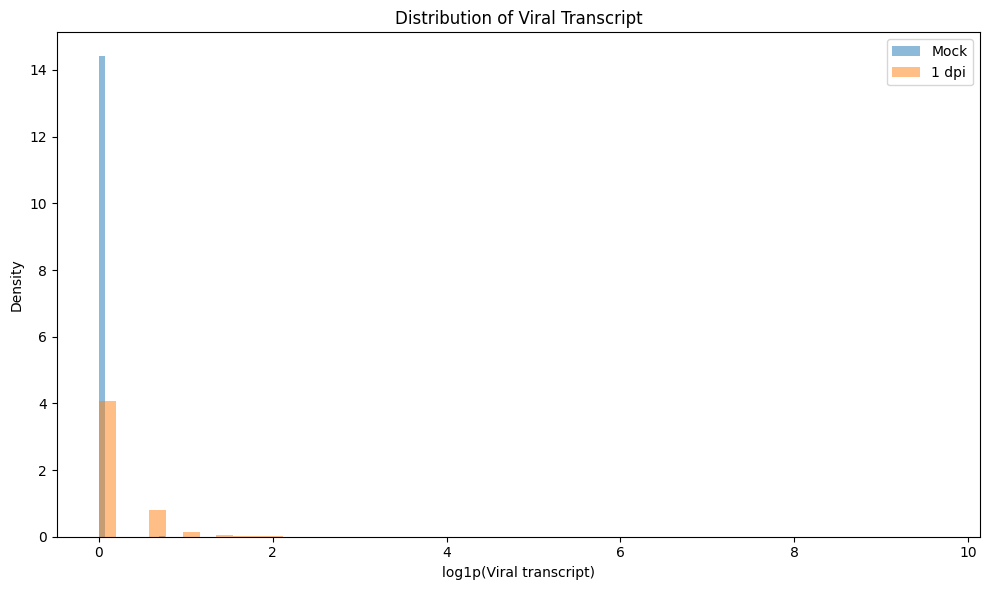

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 取出 Viral transcript
# ==========================================

mock_v = mock["Viral_transcript"].dropna()
one_dpi_v = one_dpi["Viral_transcript"].dropna()

# ==========================================
# 2. Log1p transformation
# ==========================================

mock_log = np.log1p(mock_v)
one_dpi_log = np.log1p(one_dpi_v)

# ==========================================
# 3. 畫在同一張圖
# ==========================================

plt.figure(figsize=(10, 6))

plt.hist(
    mock_log,
    bins=50,
    alpha=0.5,
    density=True,
    label="Mock"
)

plt.hist(
    one_dpi_log,
    bins=50,
    alpha=0.5,
    density=True,
    label="1 dpi"
)

plt.xlabel("log1p(Viral transcript)")
plt.ylabel("Density")
plt.title("Distribution of Viral Transcript")
plt.legend()
plt.tight_layout()

plt.show()

In [11]:
describe_table = pd.DataFrame({
    "Mock": mock_v.describe(),
    "1 dpi": one_dpi_v.describe()
})

print(describe_table)

               Mock         1 dpi
count  22107.000000  10624.000000
mean       0.006830     28.201431
std        0.347274    438.425997
min        0.000000      0.000000
25%        0.000000      0.000000
50%        0.000000      0.000000
75%        0.000000      0.000000
max       31.000000  15587.000000


In [10]:
top_3000_gene = pd.read_csv(r"C:\Users\USER\Desktop\資訊所實習\計畫\資料探勘\Ravindra2021.raw_count.stdprep.h5ad的細胞標籤\GCN_genes.csv")

In [11]:
print(top_3000_gene.head())

        0
0   ISG15
1  TTLL10
2  TAS1R3
3  CFAP74
4   GABRD


In [12]:
import scanpy as sc

adata = sc.read_h5ad(r"C:\Users\USER\Desktop\資訊所實習\計畫\資料探勘\Ravindra2021.raw_count.stdprep.h5ad")

In [15]:
unknown_prediction = pd.read_csv(r"C:\Users\USER\Desktop\資訊所實習\計畫\資料探勘\Ravindra2021.raw_count.stdprep.h5ad的細胞標籤\GCN_unknown_prediction.csv")

In [16]:
print(unknown_prediction.head())

                         Unnamed: 0           ctype Condition  \
0  AAACCCACAACCGCTG-1-1dpi_CoV2_HCR  Ciliated cells      1dpi   
1  AAACCCACACACAGAG-1-1dpi_CoV2_HCR     Basal cells      1dpi   
2  AAACCCACATCTAACG-1-1dpi_CoV2_HCR  Ciliated cells      1dpi   
3  AAACCCAGTCCCGGTA-1-1dpi_CoV2_HCR      Tuft cells      1dpi   
4  AAACCCAGTTAGCGGA-1-1dpi_CoV2_HCR      Club cells      1dpi   

   Viral_transcript  label label_source  predict_label  infect_prob  
0                 0     -1      unknown              0     0.395334  
1                 0     -1      unknown              1     0.718097  
2                 2     -1      unknown              1     0.999952  
3                 0     -1      unknown              0     0.053984  
4                 0     -1      unknown              1     0.547158  


In [21]:
ct = pd.crosstab(
    unknown_prediction["ctype"],
    unknown_prediction["predict_label"]
)

print(ct)
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(ct)

print("Chi-square:", chi2)
print("df:", dof)
print("p-value:", p)


predict_label            0      1
ctype                            
BC/Club                145   2206
Basal cells           6439  12891
Ciliated cells        2794  12378
Club cells            5261   7041
Goblet cells            58     16
Ionocytes              472     58
Neuroendocrine cells   106    193
Tuft cells             198     39
Chi-square: 3881.9965838153335
df: 7
p-value: 0.0


In [20]:
infection_rate = (
    unknown_prediction
    .groupby("ctype")["predict_label"]
    .mean()
    .sort_values(ascending=False)
)

print(infection_rate)

ctype
BC/Club                 0.938324
Ciliated cells          0.815845
Basal cells             0.666891
Neuroendocrine cells    0.645485
Club cells              0.572346
Goblet cells            0.216216
Tuft cells              0.164557
Ionocytes               0.109434
Name: predict_label, dtype: float64
